In [ ]:
#Import libraries 
from pathlib import Path
import re
import json
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fasttext

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

#Set random seeds to ensure reproducibility of results
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

#Experiment parameters 
chunk_size = 2000
max_iteration = 30
TARGET_QUAL_AUTO = 2000
test_per_class = 20

# Dynamic confidence schedule
TAU_START = 0.70
TAU_END = 0.92
ramp_iteration = max_iteration

# Class imbalance controls
max_quant_to_qual_ratio= 1.5
max_quant_add_per_iteratioon= 200
undersample_quant_to_tual = 1.5

# Heuristic candidate review sample
heuristic_sample_frac = 0.03

base_dir = Path.cwd().parent
data_dir = base_dir / "data"
output_dir = base_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True)



## Dataset Preparation and Reduction

The original dataset used in this project is the **arXiv metadata snapshot**, which is distributed as a large JSON file. Because the file is very large  and requires significant processing time to load, the dataset is first **preprocessed and reduced** to create a smaller working dataset that can be reused across experiments.

### Loading the Raw Dataset

The full dataset is loaded using `pandas.read_json()` with the `lines=True` parameter, since the arXiv metadata file is stored in JSON Lines format. To ensure reproducibility while maintaining randomness in the dataset order, the records are shuffled using a fixed random seed.

```python
arxiv_full_df = pd.read_json(
    "/Users/brandidennis/Desktop/Final Project/notebooks/arxiv-metadata-oai-snapshot.json",
    lines=True
)

arxiv_full_df = arxiv_full_df.sample(frac=1, random_state=42).reset_index(drop=True)
```

After loading, basic inspection is performed to verify the dataset structure, including the total number of records, column names, and completeness of key fields such as the category labels.

### Filtering for Computer Science Papers

The arXiv repository contains papers from many disciplines. Since this project focuses on **methodology classification within computer science research**, the dataset is filtered to include only records whose category labels begin with `"cs."`.

```python
def has_cs_category(cat_str: str) -> bool:
    if pd.isna(cat_str):
        return False
    return any(token.startswith("cs.") for token in str(cat_str).split())

cs_df = arxiv_full_df[arxiv_full_df["categories"].apply(has_cs_category)].copy()
```

This filtering step significantly reduces the dataset size while ensuring that the remaining records belong to the target research domain.

### Selecting Relevant Fields

The original arXiv metadata contains many . However, for the purposes of text classification, only the **title and abstract** fields are required. Therefore, the dataset is reduced to these columns and assigned a stable document identifier.

```python
cs_df = cs_df[["title", "abstract"]].copy().reset_index(drop=True)

cs_df["doc_id"] = np.arange(1, len(cs_df) + 1)

cs_df["label"] = ""
```
The `label` column is included to store manually assigned methodology labels during later stages of the annotation and training process.

### Saving the Reduced Dataset

Because loading and filtering the raw JSON file is computationally expensive, the reduced dataset is saved as a CSV file. This allows the notebook to load a much smaller file in future runs, greatly reducing preprocessing time.

```python
cs_df.to_csv("data.csv", index=False)
```

Experiments in the notebook operate on this reduced dataset (`data.csv`) rather than  loading the full arXiv metadata file.

In [2]:
# Load the full dataset containing research abstracts
cs_df = pd.read_csv(data_dir / "data.csv")

In [3]:
# These lists represent manually identified document indices
# for qualitative and quantitative samples 
qual_doc_ids_0 = [
    74, 466, 654, 883, 1328, 1857, 2079, 2210, 2350, 2658,
    2906, 3210, 3349, 3375, 3377, 3655, 3685, 3817, 3912, 3913,
    3923, 4130, 4231, 4264, 4285, 4341, 4463, 4532, 4798, 4944,
    5036, 5134, 5408, 5523, 5598, 5605, 5744, 5975, 5984, 6159,
    6517, 7613, 8076, 8158, 8512, 9059, 9581, 9695, 9911, 10677,
    10681, 11238, 11283, 11327, 11533, 11792, 12178, 12540,
    13089, 13102, 13182, 13580, 14319, 15011, 15356, 15411,
    15578, 16673, 16915, 16953, 17392, 17404, 18067, 18129,
    18179, 19013, 19537, 19634, 19653, 19679, 19864, 20045,
    20203, 20274, 20536, 20805, 20992, 20993, 21118, 21412,
    21558, 21723, 21771, 22659, 23137, 23454, 23464, 23525,
    23647, 23974, 24073, 24150, 24742, 24877, 25002, 25548,
    25601, 25914, 26285, 26318, 26361, 26414, 26440, 26583,
    27347, 27777, 28408, 28515, 28572, 28585
]

quant_doc_ids_0 = [
    2, 21, 23, 108, 133, 178, 211, 239, 243, 244,
    301, 309, 393, 458, 462, 527, 542, 689, 744, 803,
    927, 929, 992, 1010, 1024, 1055, 1073, 1100, 1102, 1135,
    1171, 1240, 1348, 1391, 1404, 1413, 1446, 1468, 1480, 1520,
    1548, 1549, 1578, 1585, 1610, 1638, 1653, 1696, 1724, 1810,
    1837, 1847, 1897, 1954, 1996, 2006, 2019, 2058, 2081, 2095,
    2154, 2214, 2227, 2286, 2319, 2348, 2355, 2386, 2399, 2431,
    2456, 2465, 2472, 2473, 2650, 2681, 2702, 2730, 2757, 2811,
    2850, 2880, 2881, 2885, 2931, 2979, 2990, 2991, 3001, 3028,
    3117, 3131, 3148, 3151, 3157, 3163, 3230, 3231, 3263, 3267,
    3312, 3319, 3409, 3451, 3453, 3594, 3613, 3730, 3742, 3752,
    3768, 3852, 3898, 3907, 3908, 3985, 4001, 4026, 4036, 4037 ]

In [4]:
label_qual = "qualitative"
label_quant = "quantitative"

#Quantitative and qualitative patterns chosen based on obervation
quant_patterns = r"""
(?:accuracy|precision|recall|f1[-\s]?scores?|roc|auc)|
(?:error\s?rate|rmse|mae|mse)|
(?:runtime|latency|throughput|speedup|memory\s+usage)|
(?:benchmark|evaluation|experiment(?:s)?|results?|performance)
"""

qual_patterns = r"""
(?:interview(?:s)?|focus\s+group(?:s)?|participant(?:s)?)|
(?:thematic\s+analysis|content\s+analysis|grounded\s+theory)|
(?:ethnograph(?:y|ic)|case\s+study|field\s+study)|
(?:qualitative\s+study|qualitative\s+analysis)|
(?:coding\s+scheme|open\s+coding|axial\s+coding)|
(?:narrative\s+analysis|discourse\s+analysis)|
(?:human[-\s]?cent(?:e|er)ed|user\s+study|user\s+research)|
(?:survey\s+responses?|questionnaire\s+responses?)|
(?:nvivo|atlas\.ti)
"""

#Create a mask to identify potential qualitative samples AND explicitly excludes those that also contain quantitative indicators.
qual_mask = (
    cs_df["abstract"].str.contains(qual_patterns, case=False, na=False, regex=True)
    & ~cs_df["abstract"].str.contains(quant_patterns, case=False, na=False, regex=True)
)
#Create a mask to identify potential qualitative samples
quant_mask = cs_df["abstract"].str.contains(quant_patterns, case=False, na=False, regex=True)

qual_candidates = cs_df.loc[qual_mask, ["doc_id", "title", "abstract"]].copy()
quant_candidates = cs_df.loc[quant_mask, ["doc_id", "title", "abstract"]].copy()

# Approx 3% review pool 

qual_review_pool = qual_candidates.sample(frac=heuristic_sample_frac, random_state=RANDOM_SEED)
quant_review_pool = quant_candidates.sample(frac=heuristic_sample_frac, random_state=RANDOM_SEED)

print("heuristic candidates (qual, quant):", len(qual_candidates), len(quant_candidates))
print("heuristic ratio qual:quant =", f"{len(qual_candidates)}:{len(quant_candidates)}")
print("manual review pool 3% (qual, quant):", len(qual_review_pool), len(quant_review_pool))

# Holdout test split 
qual_test_ids = random.sample(list(qual_doc_ids_0), min(test_per_class, len(qual_doc_ids_0)))
quant_test_ids = random.sample(list(quant_doc_ids_0), min(test_per_class, len(quant_doc_ids_0)))
test_ids = set(qual_test_ids + quant_test_ids)

qual_train_ids = [x for x in qual_doc_ids_0 if x not in test_ids]
quant_train_ids = [x for x in quant_doc_ids_0 if x not in test_ids]

seed0_qual = cs_df.loc[cs_df["doc_id"].isin(qual_train_ids), ["doc_id", "title", "abstract"]].copy()
seed0_quant = cs_df.loc[cs_df["doc_id"].isin(quant_train_ids), ["doc_id", "title", "abstract"]].copy()

seed0_qual["label"] = label_qual
seed0_quant["label"] = label_quant

train_seed = pd.concat([seed0_qual, seed0_quant], ignore_index=True).drop_duplicates(subset="doc_id", keep="first")
train_seed.to_csv(output_dir / "train_seed_stage0.csv", index=False)

test_df = cs_df.loc[cs_df["doc_id"].isin(test_ids), ["doc_id", "title", "abstract"]].copy()
test_df["y_true"] = np.where(test_df["doc_id"].isin(set(qual_test_ids)), label_qual, label_quant)
test_df.to_csv(output_dir / "test_df_stage0.csv", index=False)

print("stage0 train_seed:", train_seed.shape)
print(train_seed["label"].value_counts())
print("test_df:", test_df.shape)

heuristic candidates (qual, quant): 4331 25414
heuristic ratio qual:quant = 4331:25414
manual review pool 3% (qual, quant): 130 762
stage0 train_seed: (200, 4)
label
qualitative     100
quantitative    100
Name: count, dtype: int64
test_df: (40, 4)


Total CS papers: 850305
Median abstract words: 166
P10/P90 words: [100 237]


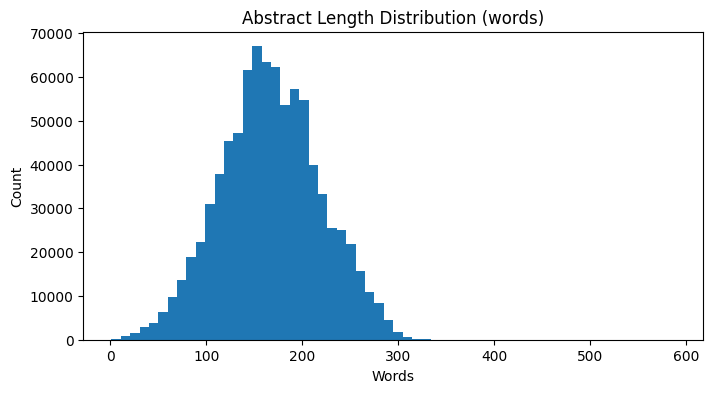

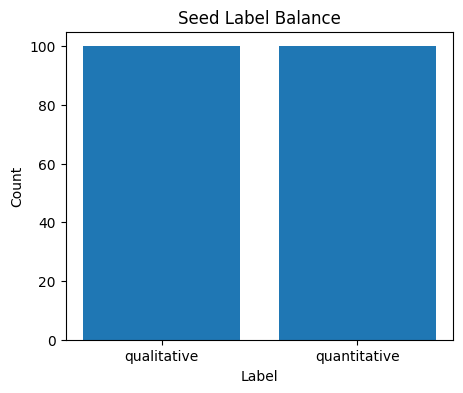


Seed samples per label:
label
qualitative     100
quantitative    100
Name: count, dtype: int64

Abstract length stats by label:
              count   mean  median  min  max
label                                       
qualitative     100  180.5   178.5   57  301
quantitative    100  179.6   174.5   35  302


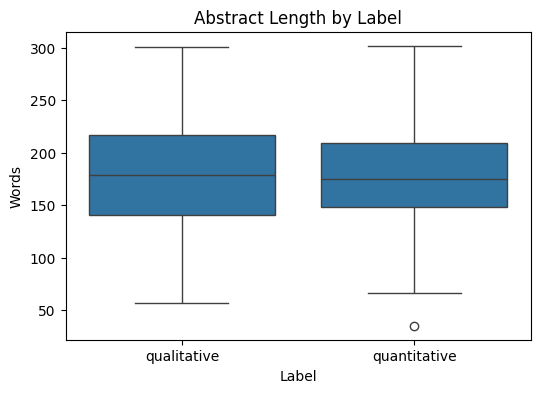

In [5]:
# Create  copy of the dataset to avoid modifying the original
eda_df = cs_df.copy()

eda_df["abstract"] = eda_df["abstract"].fillna("").astype(str)
eda_df["abstract_len_words"] = eda_df["abstract"].apply(lambda x: len(x.split()))

print("Total CS papers:", len(eda_df))
print("Median abstract words:", int(eda_df["abstract_len_words"].median()))
print("P10/P90 words:", np.percentile(eda_df["abstract_len_words"], [10, 90]).astype(int))

plt.figure(figsize=(8, 4))
plt.hist(eda_df["abstract_len_words"], bins=60)
plt.title("Abstract Length Distribution (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

seed_counts = train_seed["label"].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(seed_counts.index.astype(str), seed_counts.values)
plt.title("Seed Label Balance")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

seed_len = train_seed.copy()
seed_len["abstract_len_words"] = seed_len["abstract"].str.split().str.len()

print("\nSeed samples per label:")
print(seed_len["label"].value_counts())

print("\nAbstract length stats by label:")
print(
    seed_len.groupby("label")["abstract_len_words"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
)

plt.figure(figsize=(6, 4))
sns.boxplot(data=seed_len, x="label", y="abstract_len_words")
plt.title("Abstract Length by Label")
plt.xlabel("Label")
plt.ylabel("Words")
plt.show()
